# Comparativa de samplers — VP Exponential

Se fija el proceso **VP con schedule exponencial** (mejor FID en la comparativa VE vs VP) y se evalúan los tres integradores disponibles:

| Sampler | Tipo | Descripción |
|---|---|---|
| **Euler–Maruyama (EM)** | Estocástico | Integrador SDE de primer orden |
| **Predictor–Corrector (PC)** | Estocástico | EM + pasos de Langevin correctores |
| **Probability Flow ODE** | Determinista | ODE equivalente, sin término difusivo |

**Métricas:**
- **FID** — métrica principal para comparar samplers (calidad de las imágenes generadas).
- **BPD** — *bits per dimension* via la probability flow ODE (log-verosimilitud del modelo, no del sampler; se computa una sola vez sobre imágenes reales).

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision.transforms import ToTensor
import pandas as pd

from diffusion_lib import (
    VPProcess, CosineSchedule,
    EulerMaruyamaSampler,
    PredictorCorrectorSampler,
    ProbabilityFlowODESampler,
    GenerativeDiffusionModel,
    compute_bpd,
)
from diffusion_lib import UNetScoreModelColor as ScoreNetColor
from diffusion_lib.metrics.fid_is import compute_fid

DEVICE    = 'mps'
N_IMAGES  = 500   # imágenes generadas para FID
N_STEPS   = 1500   # pasos de integración
N_BPD     = 100   # imágenes reales para BPD (más lento por autograd)
IMG_SHAPE = (3, 32, 32)
CKPT      = 'color_digits_checkpoints/color_digits_VP-Cosine.pth'
SEED      = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device: {DEVICE}')

Device: mps


## 1 · Imágenes reales — SVHN

In [25]:
import scipy.io
from pathlib import Path as _Path

# Carga directa desde el .mat (mismo método que conditional_and_imputation)
_PROJECT_DIR = _Path.cwd()
if not (_PROJECT_DIR / 'diffusion_lib').exists():
    _PROJECT_DIR = _PROJECT_DIR.parent

mat = scipy.io.loadmat(str(_PROJECT_DIR / 'data' / 'MNIST' / 'raw' / 'train_32x32.mat'))
X_all = np.transpose(mat['X'], (3, 2, 0, 1)).astype(np.float32) / 255.0  # (N, 3, 32, 32)

subset_idx  = np.random.choice(len(X_all), size=N_IMAGES, replace=False)
real_images = torch.from_numpy(X_all[subset_idx])  # (N_IMAGES, 3, 32, 32)
print(f'Real images : {real_images.shape}  '
      f'min={real_images.min():.3f}  max={real_images.max():.3f}')

# Subconjunto más pequeño para BPD (computacionalmente costoso)
bpd_images = real_images[:N_BPD].to(DEVICE)
print(f'BPD subset  : {bpd_images.shape}')

Real images : torch.Size([500, 3, 32, 32])  min=0.000  max=1.000
BPD subset  : torch.Size([100, 3, 32, 32])


## 2 · Modelo VP-Cosine (carga única)

El mismo checkpoint se usa con los tres samplers — solo varía el integrador de la SDE/ODE backward.

In [26]:
vp_cos_process = VPProcess(schedule=CosineSchedule())

score_model = ScoreNetColor(marginal_prob_std=vp_cos_process.sigma_t).to(DEVICE)
ckpt = torch.load(CKPT, map_location=DEVICE, weights_only=True)
score_model.load_state_dict(ckpt)
score_model.eval()
print('VP-Cosine checkpoint cargado.')

# Instancias de los tres samplers
sampler_em  = EulerMaruyamaSampler()
sampler_pc  = PredictorCorrectorSampler(n_corrector_steps=1, snr=0.16)
sampler_ode = ProbabilityFlowODESampler()

# Modelos generativos (mismo proceso y score model, distinto sampler)
gm_em  = GenerativeDiffusionModel(vp_cos_process, sampler_em,  score_model, DEVICE, T=0.999)
gm_pc  = GenerativeDiffusionModel(vp_cos_process, sampler_pc,  score_model, DEVICE, T=0.999)
gm_ode = GenerativeDiffusionModel(vp_cos_process, sampler_ode, score_model, DEVICE, T=0.999)

print('Modelos instanciados: EM / PC / ODE')

VP-Cosine checkpoint cargado.
Modelos instanciados: EM / PC / ODE


## 3 · Generación de muestras con cada sampler

In [27]:
print(f'Generando {N_IMAGES} imágenes con Euler–Maruyama ...')
with torch.no_grad():
    fake_em = gm_em.sample(n_images=N_IMAGES, img_shape=IMG_SHAPE, n_steps=N_STEPS)
fake_em = fake_em.clamp(0., 1.).cpu()
print(f'  EM  : {fake_em.shape}')

print(f'Generando {N_IMAGES} imágenes con Predictor–Corrector ...')
with torch.no_grad():
    fake_pc = gm_pc.sample(n_images=N_IMAGES, img_shape=IMG_SHAPE, n_steps=N_STEPS)
fake_pc = fake_pc.clamp(0., 1.).cpu()
print(f'  PC  : {fake_pc.shape}')

print(f'Generando {N_IMAGES} imágenes con Probability Flow ODE ...')
with torch.no_grad():
    fake_ode = gm_ode.sample(n_images=N_IMAGES, img_shape=IMG_SHAPE, n_steps=N_STEPS)
fake_ode = fake_ode.clamp(0., 1.).cpu()
print(f'ODE : {fake_ode.shape}')

Generando 500 imágenes con Euler–Maruyama ...
  EM  : torch.Size([500, 3, 32, 32])
Generando 500 imágenes con Predictor–Corrector ...
  PC  : torch.Size([500, 3, 32, 32])
Generando 500 imágenes con Probability Flow ODE ...
ODE : torch.Size([500, 3, 32, 32])


## 4 · FID por sampler

$$\text{FID} = \|\mu_r - \mu_f\|^2 + \operatorname{Tr}\!\left(\Sigma_r + \Sigma_f - 2(\Sigma_r\Sigma_f)^{1/2}\right)$$

Características de InceptionV3 `pool_3` (2048-dim), imágenes redimensionadas a $299\times299$. **Menor FID = mejor.**

In [28]:
fid_em  = compute_fid(real_images, fake_em,  device=DEVICE)
fid_pc  = compute_fid(real_images, fake_pc,  device=DEVICE)
fid_ode = compute_fid(real_images, fake_ode, device=DEVICE)

print(f'FID  Euler–Maruyama      : {fid_em:.2f}')
print(f'FID  Predictor–Corrector : {fid_pc:.2f}')
print(f'FID  Probability Flow ODE: {fid_ode:.2f}')

FID  Euler–Maruyama      : 142.46
FID  Predictor–Corrector : 146.97
FID  Probability Flow ODE: 143.54


## 5 · BPD via Probability Flow ODE

El BPD **no depende del sampler**: se calcula corriendo el ODE *hacia adelante* ($\mathbf{x}_0 \to \mathbf{x}_T$) con el estimador de traza de Hutchinson:

$$\log p_0(\mathbf{x}_0) = \log p_T(\mathbf{x}_T) + \int_{\varepsilon}^{T} \operatorname{div}\left[f_{\text{ODE}}(\mathbf{x}_t,t)\right]\,dt, \qquad \text{BPD} = \frac{-\log p_0(\mathbf{x}_0)}{D\log 2}$$

Se evalúa sobre `N_BPD` imágenes reales. **Menor BPD = mejor.**

In [29]:
print(f'Calculando BPD sobre {N_BPD} imágenes reales (puede tardar varios minutos) ...')
bpd_vals = compute_bpd(
    score_model=score_model,
    process=vp_cos_process,
    x_0=bpd_images,
    n_steps=100,
    n_hutchinson=1,
)
bpd_mean = bpd_vals.mean().item()
bpd_std  = bpd_vals.std().item()
print(f'BPD  VP-Cosine (ODE): {bpd_mean:.3f} ± {bpd_std:.3f} bpd')

Calculando BPD sobre 100 imágenes reales (puede tardar varios minutos) ...
BPD  VP-Cosine (ODE): -10.141 ± 1.703 bpd


## 6 · Comparativa visual

8 imágenes reales + 8 muestras generadas por cada sampler.

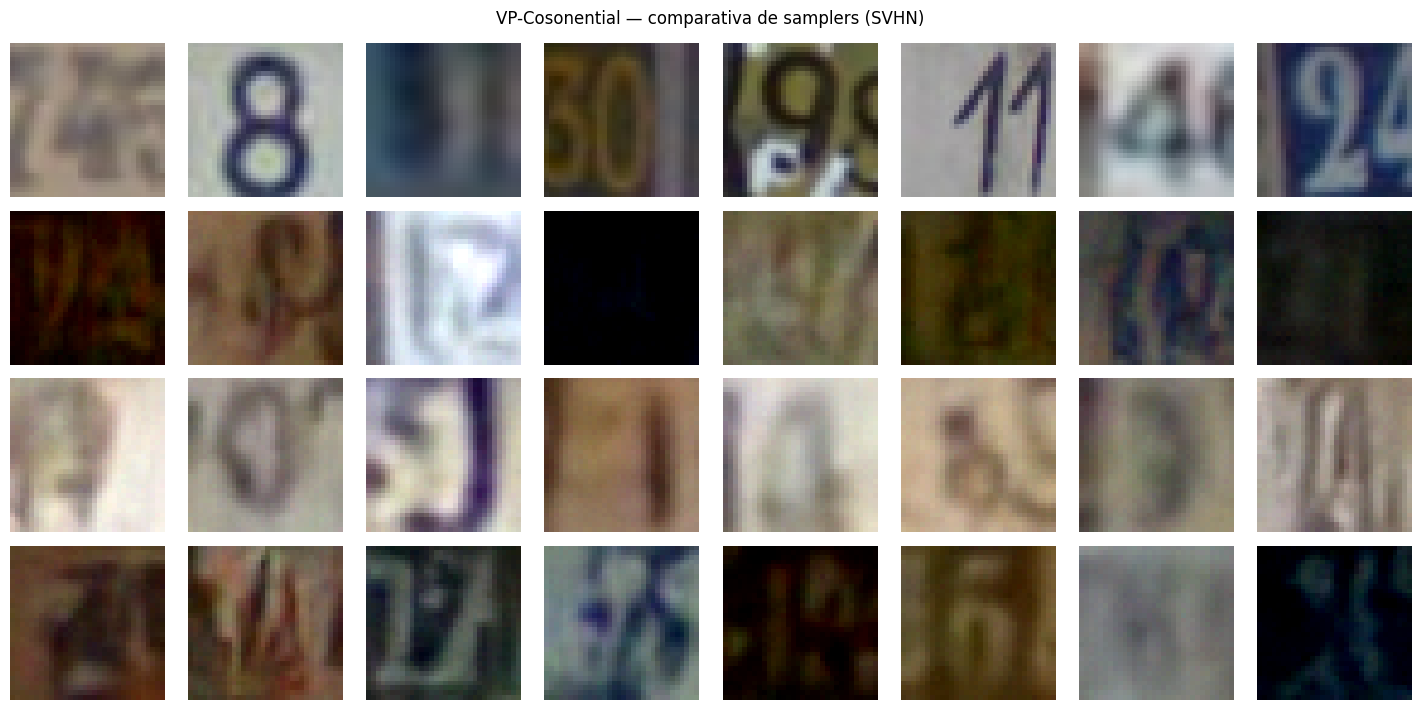

Guardado samplers_vp_cos_comparison.png


In [30]:
N_SHOW = 8
idx = torch.randperm(real_images.shape[0])[:N_SHOW]

fig, axes = plt.subplots(4, N_SHOW, figsize=(N_SHOW * 1.8, 4 * 1.8))

row_data = [
    ('Real SVHN',                                 real_images[idx]),
    (f'VP-Cos  EM    FID={fid_em:.1f}',           fake_em[torch.randperm(fake_em.shape[0])[:N_SHOW]]),
    (f'VP-Cos  PC    FID={fid_pc:.1f}',           fake_pc[torch.randperm(fake_pc.shape[0])[:N_SHOW]]),
    (f'VP-Cos  ODE   FID={fid_ode:.1f}',          fake_ode[torch.randperm(fake_ode.shape[0])[:N_SHOW]]),
]

for row, (label, batch) in enumerate(row_data):
    for col in range(N_SHOW):
        img = batch[col].permute(1, 2, 0).numpy()
        axes[row, col].imshow(np.clip(img, 0., 1.))
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=0, labelpad=120, va='center')

plt.suptitle('VP-Cosonential — comparativa de samplers (SVHN)', fontsize=12)
plt.tight_layout()
import pathlib; pathlib.Path('Figuras').mkdir(exist_ok=True)
plt.savefig('Figuras/samplers_vp_cos_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado samplers_vp_cos_comparison.png')

## 7 · Tabla resumen

In [31]:
df = pd.DataFrame({
    'Sampler'    : ['Euler–Maruyama', 'Predictor–Corrector', 'Probability Flow ODE'],
    'Tipo'       : ['Estocástico', 'Estocástico', 'Determinista'],
    'N pasos'    : [N_STEPS] * 3,
    'N imágenes' : [N_IMAGES] * 3,
    'FID ↓'      : [round(fid_em, 2), round(fid_pc, 2), round(fid_ode, 2)],
    'BPD ↓'      : ['-', '-', f'{bpd_mean:.3f} ± {bpd_std:.3f}'],
})
df.set_index('Sampler', inplace=True)
print(df.to_string())

                              Tipo  N pasos  N imágenes   FID ↓            BPD ↓
Sampler                                                                         
Euler–Maruyama         Estocástico     1500         500  142.46                -
Predictor–Corrector    Estocástico     1500         500  146.97                -
Probability Flow ODE  Determinista     1500         500  143.54  -10.141 ± 1.703
